In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Cargar el archivo cargado en Colab
df = pd.read_csv('ad_viz_plotval_data.csv')

# Visualizar las primeras filas y columnas
df.head()

,Date,Source,Site ID,POC,Daily Max 1-hour SO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,10730023,2,0.0,ppb,0,North Birmingham,24,100.0,42401,Sulfur dioxide,100,13820,"Birmingham-Hoover, AL",1,Alabama,73,Jefferson,33.553056,-86.815
1,01/02/2023,AQS,10730023,2,0.9,ppb,0,North Birmingham,24,100.0,42401,Sulfur dioxide,100,13820,"Birmingham-Hoover, AL",1,Alabama,73,Jefferson,33.553056,-86.815
2,01/03/2023,AQS,10730023,2,0.3,ppb,0,North Birmingham,24,100.0,42401,Sulfur dioxide,100,13820,"Birmingham-Hoover, AL",1,Alabama,73,Jefferson,33.553056,-86.815
3,01/04/2023,AQS,10730023,2,0.6,ppb,0,North Birmingham,24,100.0,42401,Sulfur dioxide,100,13820,"Birmingham-Hoover, AL",1,Alabama,73,Jefferson,33.553056,-86.815
4,01/06/2023,AQS,10730023,2,1.7,ppb,1,North Birmingham,19,79.0,42401,Sulfur dioxide,100,13820,"Birmingham-Hoover, AL",1,Alabama,73,Jefferson,33.553056,-86.815


In [105]:
# Ver nombres de columnas e información general del DataFrame
print("Columnas del dataset:")
print(df.columns)

print("\nInformación general del dataset:")
df.info()

Columnas del dataset:
Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 1-hour SO2 Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                712 non-null    object 
 1   Source                              712 non-null    object 
 2   Site ID                             712 non-null    int64  
 3   POC                                 712 non-null    int64  
 4   Daily Max 1-hour SO2 Concentration

In [106]:
# Resumen estadístico numérico
df.describe().round(1)

,Site ID,POC,Daily Max 1-hour SO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0,712.0
mean,10730518.5,1.5,1.7,1.7,23.6,98.3,42401.0,124.6,13820.0,1.0,73.0,33.5,-86.9
std,490.3,0.5,1.9,2.7,1.2,4.9,0.0,39.5,0.0,0.0,0.0,0.0,0.1
min,10730023.0,1.0,-0.5,0.0,18.0,75.0,42401.0,100.0,13820.0,1.0,73.0,33.5,-86.9
25%,10730023.0,1.0,0.5,0.0,24.0,100.0,42401.0,100.0,13820.0,1.0,73.0,33.5,-86.9
50%,10731003.0,1.0,1.2,1.0,24.0,100.0,42401.0,100.0,13820.0,1.0,73.0,33.5,-86.9
75%,10731003.0,2.0,2.1,3.0,24.0,100.0,42401.0,188.0,13820.0,1.0,73.0,33.6,-86.8
max,10731003.0,2.0,17.5,24.0,24.0,100.0,42401.0,188.0,13820.0,1.0,73.0,33.6,-86.8


Text(0.5, 1.02, 'Análisis Exploratorio Visual (Pairplot) por Estación')

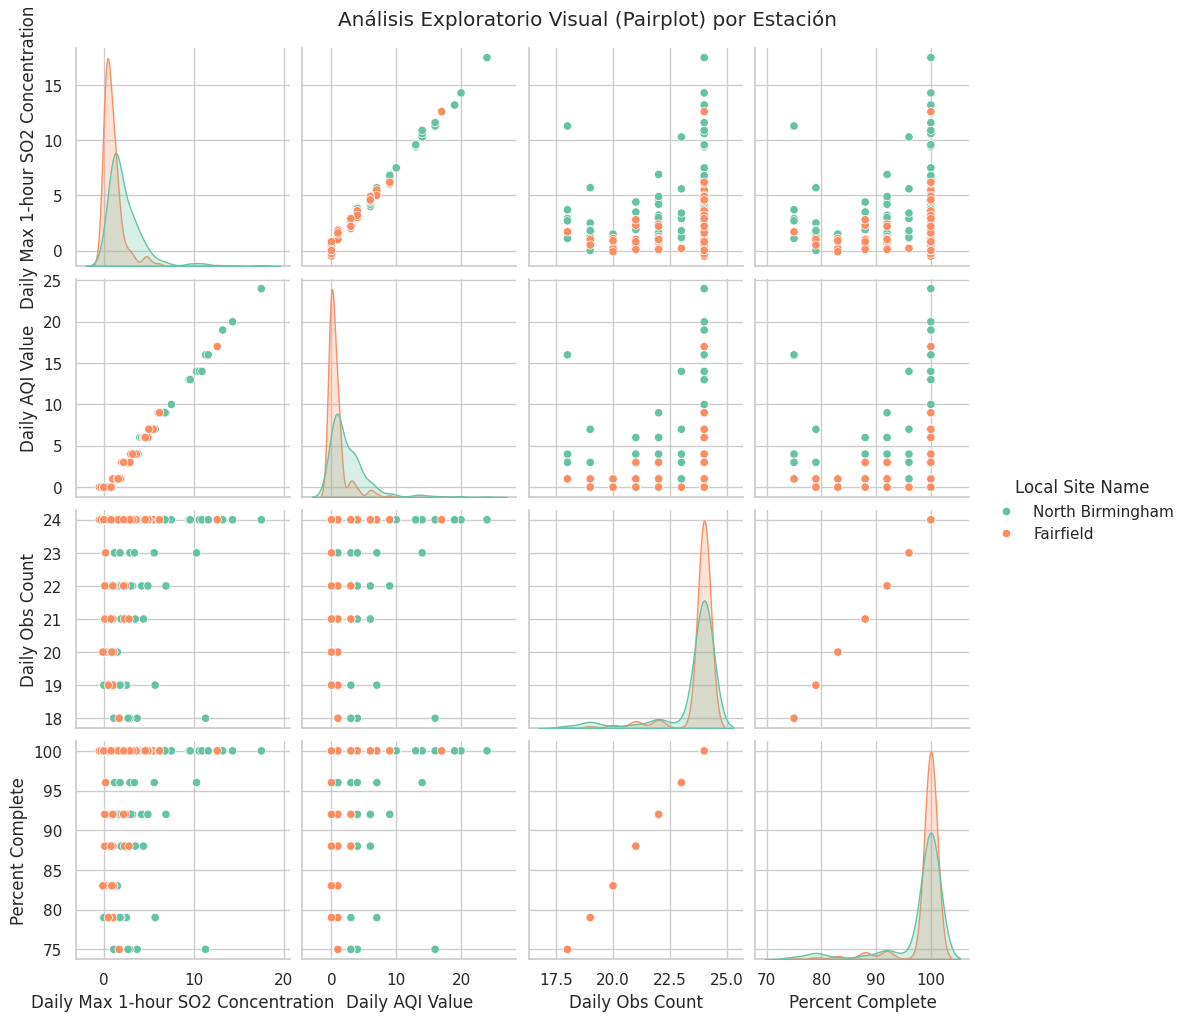

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selección de variables cuantitativas principales para el EDA
variables = ['Daily Max 1-hour SO2 Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete']

# Generación del pairplot segmentado por estación
sns.pairplot(df, vars=variables, hue='Local Site Name', palette='Set2', diag_kind='kde')
plt.suptitle('Análisis Exploratorio Visual (Pairplot) por Estación', y=1.02)
plt.show()

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Definición de variables X e Y
X = df[['Daily Max 1-hour SO2 Concentration']]
y = df['Daily AQI Value']

# División en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de Entrenamiento: {X_train.shape[0]} | Muestras de Prueba: {X_test.shape[0]}")

Muestras de Entrenamiento: 569 | Muestras de Prueba: 143


In [109]:
# Entrenar modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Métricas estadisticas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Pendiente (β1): {modelo.coef_[0]:.4f}")
print(f"Intercepto (β0): {modelo.intercept_:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")

LinearRegression()

Pendiente (β1): 1.4122
Intercepto (β0): -0.6670
Coeficiente de Determinación (R²): 0.9523
Error Cuadrático Medio (RMSE): 0.4124
Error Absoluto Medio (MAE): 0.3390


Histograma y Distribución Frecuencial (SO2)


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Daily Max 1-hour SO2 Concentration', ylabel='Count'>

Text(0.5, 1.0, '1. Distribución Frecuencial de Concentración de SO2 por Estación')

Text(0.5, 0, 'Concentración Máxima 1-hora SO2 (ppb)')

Text(0, 0.5, 'Frecuencia (Días)')

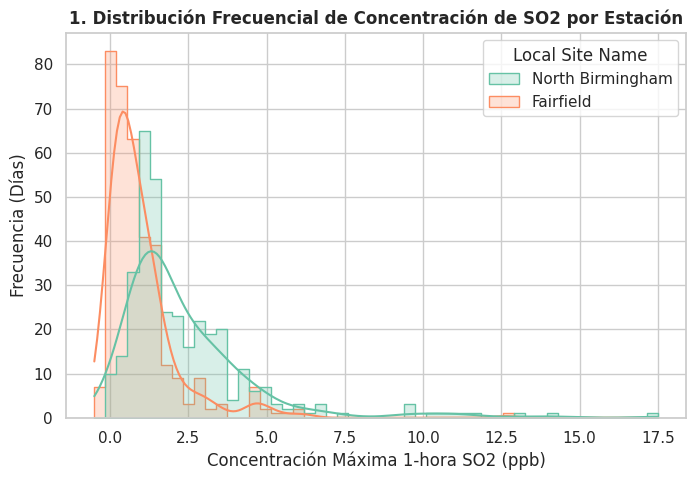

In [110]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Daily Max 1-hour SO2 Concentration', hue='Local Site Name', kde=True, element="step", palette='Set2')
plt.title('1. Distribución Frecuencial de Concentración de SO2 por Estación', fontweight='bold')
plt.xlabel('Concentración Máxima 1-hora SO2 (ppb)')
plt.ylabel('Frecuencia (Días)')
plt.show()

Diagramas de Caja (Boxplots por Estación)

/tmp/ipykernel_1605/1608413551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Local Site Name', y='Daily Max 1-hour SO2 Concentration', palette='Set2', ax=axes[0])


<Axes: xlabel='Local Site Name', ylabel='Daily Max 1-hour SO2 Concentration'>

Text(0.5, 1.0, '2A. Diagrama de Caja: SO2 por Estación')

Text(0.5, 0, 'Estación')

Text(0, 0.5, 'SO2 (ppb)')

/tmp/ipykernel_1605/1608413551.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Local Site Name', y='Daily AQI Value', palette='Set2', ax=axes[1])


<Axes: xlabel='Local Site Name', ylabel='Daily AQI Value'>

Text(0.5, 1.0, '2B. Diagrama de Caja: AQI por Estación')

Text(0.5, 0, 'Estación')

Text(0, 0.5, 'Valor AQI')

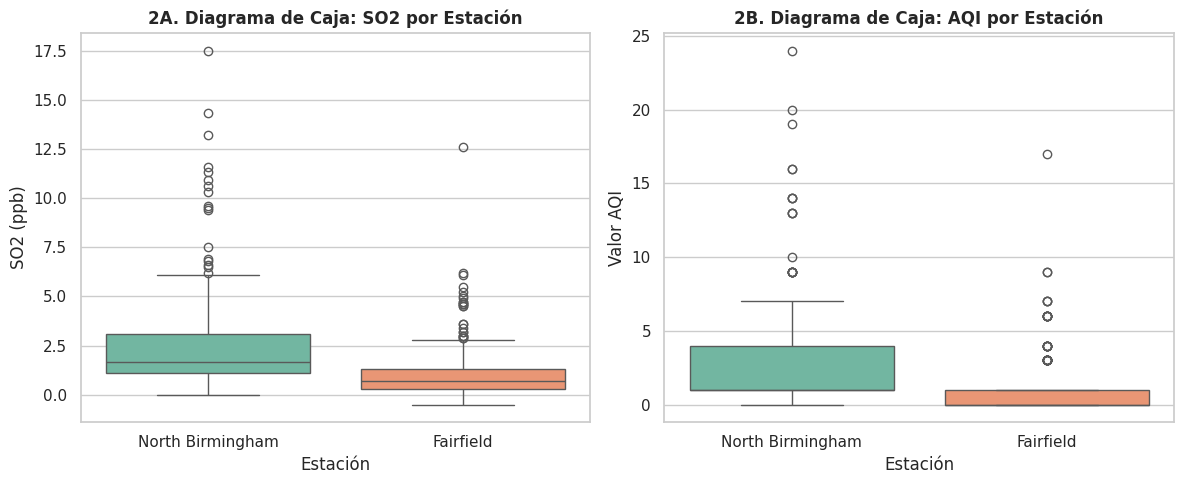

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de SO2
sns.boxplot(data=df, x='Local Site Name', y='Daily Max 1-hour SO2 Concentration', palette='Set2', ax=axes[0])
axes[0].set_title('2A. Diagrama de Caja: SO2 por Estación', fontweight='bold')
axes[0].set_xlabel('Estación')
axes[0].set_ylabel('SO2 (ppb)')

# Boxplot de AQI
sns.boxplot(data=df, x='Local Site Name', y='Daily AQI Value', palette='Set2', ax=axes[1])
axes[1].set_title('2B. Diagrama de Caja: AQI por Estación', fontweight='bold')
axes[1].set_xlabel('Estación')
axes[1].set_ylabel('Valor AQI')

plt.tight_layout()
plt.show()

Serie de Tiempo Diaria (Evolución 2023)

<Figure size 1200x500 with 0 Axes>

<Axes: xlabel='Date_dt', ylabel='Daily Max 1-hour SO2 Concentration'>

Text(0.5, 1.0, '3. Evolución Temporal Diaria de SO2 durante el Año 2023')

Text(0.5, 0, 'Fecha')

Text(0, 0.5, 'SO2 (ppb)')

(array([19358., 19417., 19478., 19539., 19601., 19662., 19723.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19417.0, 0, '2023-03'),
  Text(19478.0, 0, '2023-05'),
  Text(19539.0, 0, '2023-07'),
  Text(19601.0, 0, '2023-09'),
  Text(19662.0, 0, '2023-11'),
  Text(19723.0, 0, '2024-01')])

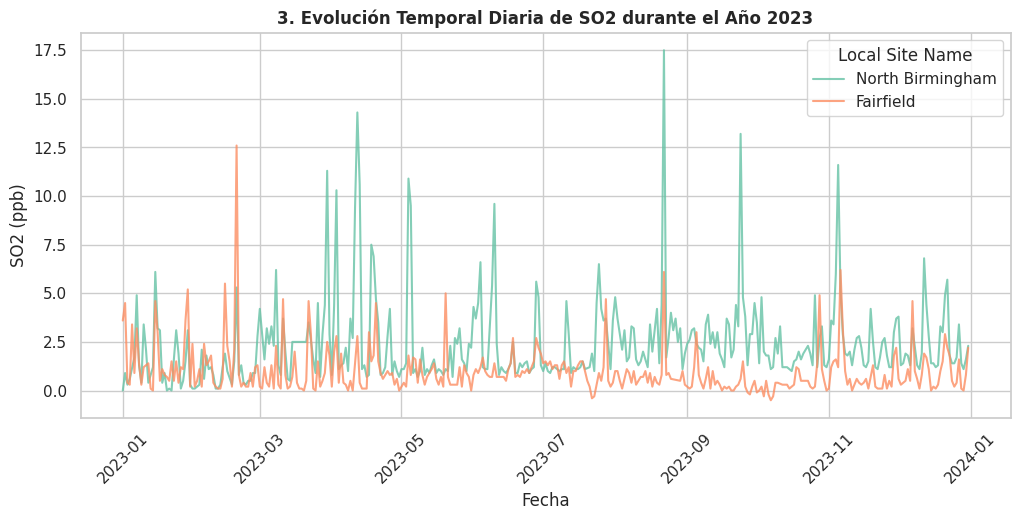

In [112]:
# Convertir/asegurar la columna Date_dt
df['Date_dt'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=df.sort_values('Date_dt'), x='Date_dt', y='Daily Max 1-hour SO2 Concentration', hue='Local Site Name', palette='Set2', alpha=0.8)
plt.title('3. Evolución Temporal Diaria de SO2 durante el Año 2023', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('SO2 (ppb)')
plt.xticks(rotation=45)
plt.show()

Promedio Mensual por Estación

<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Month', ylabel='Daily Max 1-hour SO2 Concentration'>

Text(0.5, 1.0, '4. Promedio Mensual de Concentración de SO2 por Estación')

Text(0.5, 0, 'Mes')

Text(0, 0.5, 'Promedio SO2 (ppb)')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

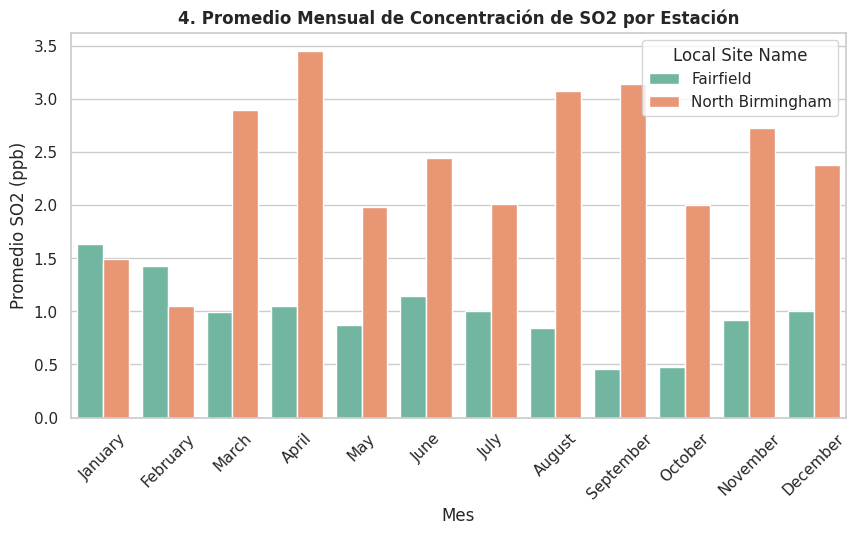

In [113]:
df['Month'] = df['Date_dt'].dt.month_name()
df['Month_Num'] = df['Date_dt'].dt.month

monthly_avg = df.groupby(['Month_Num', 'Month', 'Local Site Name'])['Daily Max 1-hour SO2 Concentration'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_avg, x='Month', y='Daily Max 1-hour SO2 Concentration', hue='Local Site Name', palette='Set2')
plt.title('4. Promedio Mensual de Concentración de SO2 por Estación', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Promedio SO2 (ppb)')
plt.xticks(rotation=45)
plt.show()

Matriz de Correlación de Pearson
Python

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, '5. Matriz de Correlación de Pearson')

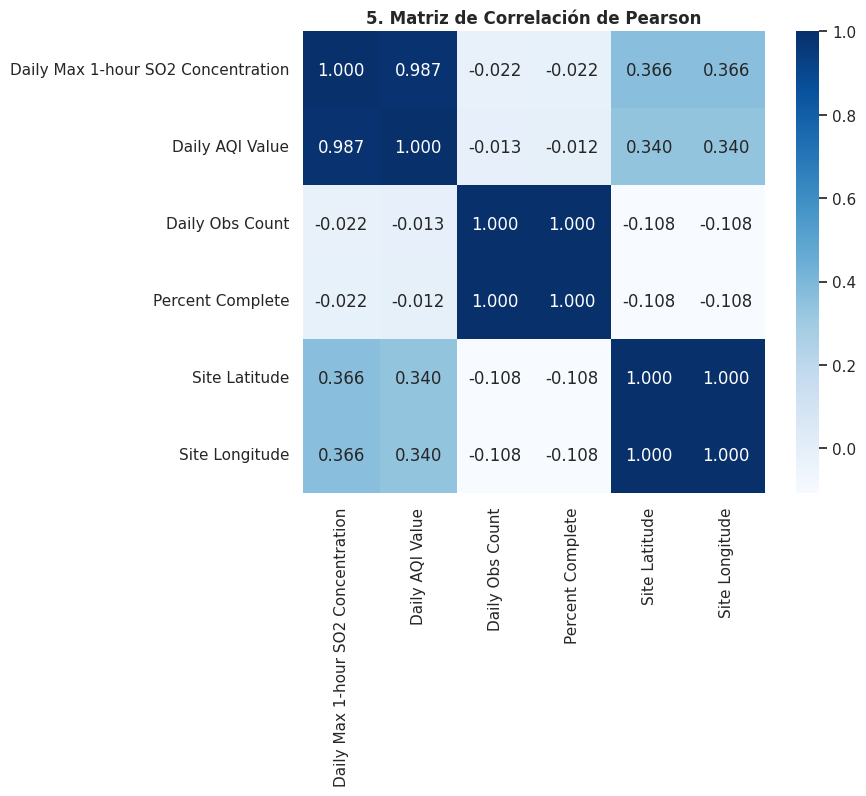

In [114]:
numeric_cols = ['Daily Max 1-hour SO2 Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'Site Latitude', 'Site Longitude']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".3f", cmap='Blues', square=True)
plt.title('5. Matriz de Correlación de Pearson', fontweight='bold')
plt.show()

División de Datos (Entrenamiento y Prueba)

In [115]:
# Variable independiente (X) y dependiente (y)
X = df[['Daily Max 1-hour SO2 Concentration']]
y = df['Daily AQI Value']

# División 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")

Muestras de Entrenamiento: 569
Muestras de Prueba: 143


Entrenamiento del Modelo de Regresión Lineal

In [116]:
# Inicializar y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

print("Entrenamiento completado.")

LinearRegression()

Entrenamiento completado.


Evaluación de Métricas del Modelo

In [117]:
# Cálculo de métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Pendiente (β1): {modelo.coef_[0]:.4f}")
print(f"Intercepto (β0): {modelo.intercept_:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")

Pendiente (β1): 1.4122
Intercepto (β0): -0.6670
Coeficiente de Determinación (R²): 0.9523
Error Cuadrático Medio (RMSE): 0.4124
Error Absoluto Medio (MAE): 0.3390


Ajuste de Regresión y Diagnóstico de Residuos

<Axes: xlabel='Daily Max 1-hour SO2 Concentration', ylabel='Daily AQI Value'>

Text(0.5, 1.0, 'Regresión Lineal: SO2 vs. AQI')

Text(0.5, 0, 'Concentración Máxima 1-hora SO2 (ppb)')

Text(0, 0.5, 'Valor AQI Diario')

Text(0.5, 1.0, 'Gráfico de Residuos (Errores)')

Text(0.5, 0, 'Valores Predichos de AQI')

Text(0, 0.5, 'Residuos (Real - Predicho)')

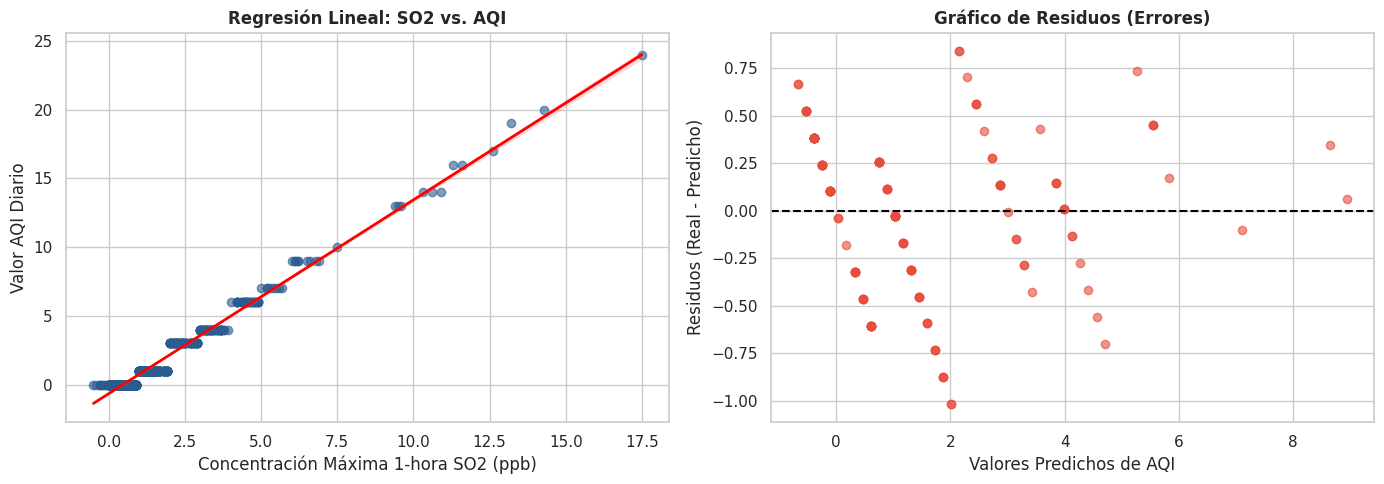

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recta de ajuste
sns.regplot(x='Daily Max 1-hour SO2 Concentration', y='Daily AQI Value', data=df, ax=axes[0],
            line_kws={'color':'red', 'linewidth':2}, scatter_kws={'alpha':0.6, 'color':'#2b5c8f'})
axes[0].set_title('Regresión Lineal: SO2 vs. AQI', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Concentración Máxima 1-hora SO2 (ppb)')
axes[0].set_ylabel('Valor AQI Diario')

# Gráfico de residuos
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.6, color='#e74c3c')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Gráfico de Residuos (Errores)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valores Predichos de AQI')
axes[1].set_ylabel('Residuos (Real - Predicho)')

plt.tight_layout()
plt.show()

Graficos de Dispersion

<Axes: xlabel='Daily Max 1-hour SO2 Concentration', ylabel='Daily AQI Value'>

Text(0.5, 1.0, '1. Concentración de SO2 vs. AQI Diario')

Text(0.5, 0, 'Concentración Máxima 1-hora SO2 (ppb)')

Text(0, 0.5, 'Valor AQI Diario')

<Axes: xlabel='Daily Max 1-hour SO2 Concentration', ylabel='Daily Obs Count'>

...

Text(0, 0.5, 'Porcentaje de Completitud (%)')

<Axes: xlabel='Daily Max 1-hour SO2 Concentration', ylabel='POC'>

Text(0.5, 1.0, '4. Concentración de SO2 vs. Código POC')

Text(0.5, 0, 'Concentración Máxima 1-hora SO2 (ppb)')

Text(0, 0.5, 'Código POC de Estación')

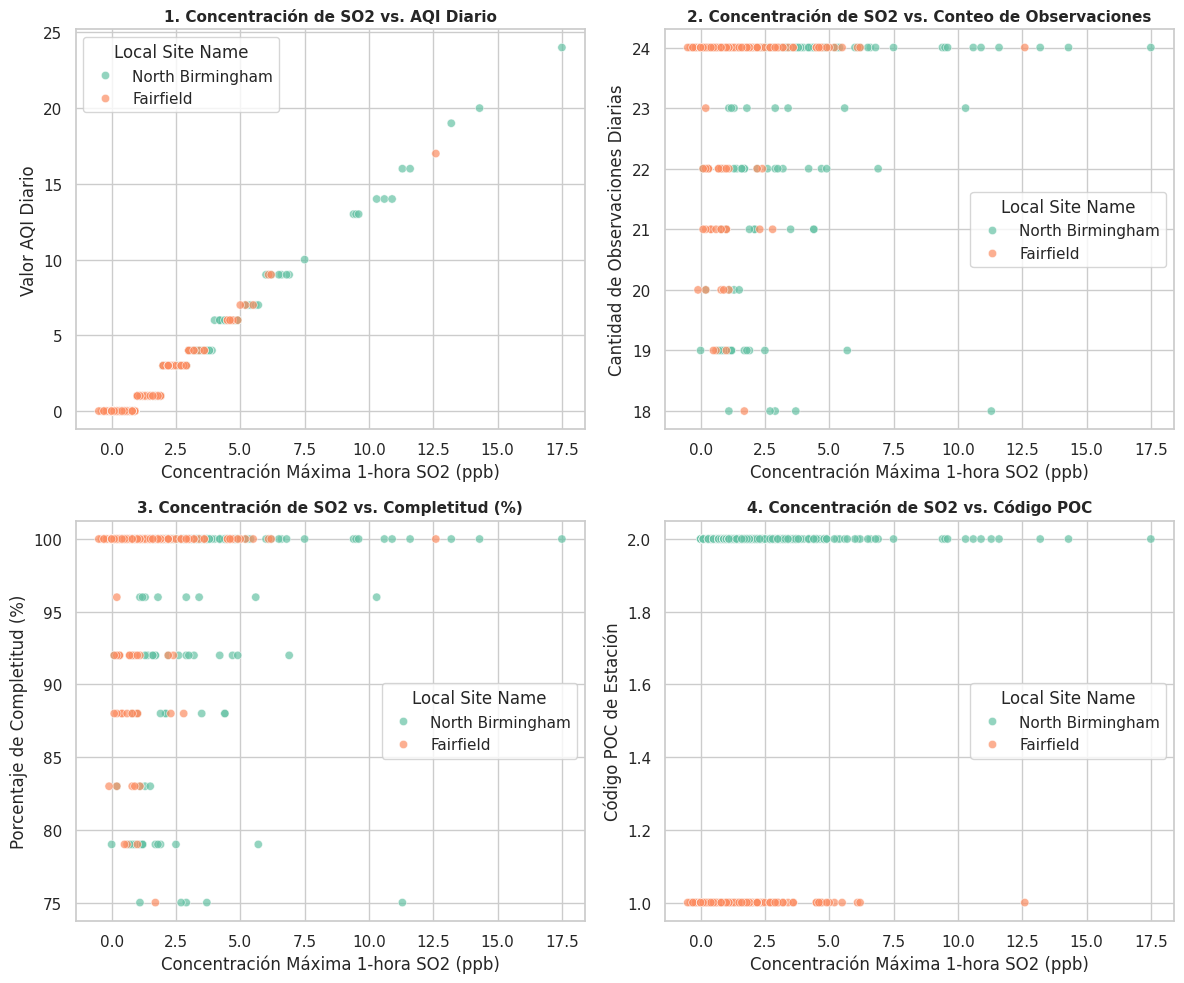

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del panel de 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. SO2 vs AQI Diario
sns.scatterplot(data=df, x='Daily Max 1-hour SO2 Concentration', y='Daily AQI Value',
                hue='Local Site Name', palette='Set2', ax=axes[0, 0], alpha=0.7)
axes[0, 0].set_title('1. Concentración de SO2 vs. AQI Diario', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Concentración Máxima 1-hora SO2 (ppb)')
axes[0, 0].set_ylabel('Valor AQI Diario')

# 2. SO2 vs Conteo de Observaciones Diarias
sns.scatterplot(data=df, x='Daily Max 1-hour SO2 Concentration', y='Daily Obs Count',
                hue='Local Site Name', palette='Set2', ax=axes[0, 1], alpha=0.7)
axes[0, 1].set_title('2. Concentración de SO2 vs. Conteo de Observaciones', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Concentración Máxima 1-hora SO2 (ppb)')
axes[0, 1].set_ylabel('Cantidad de Observaciones Diarias')

# 3. SO2 vs Porcentaje de Completitud
sns.scatterplot(data=df, x='Daily Max 1-hour SO2 Concentration', y='Percent Complete',
                hue='Local Site Name', palette='Set2', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('3. Concentración de SO2 vs. Completitud (%)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Concentración Máxima 1-hora SO2 (ppb)')
axes[1, 0].set_ylabel('Porcentaje de Completitud (%)')

# 4. SO2 vs Código POC
sns.scatterplot(data=df, x='Daily Max 1-hour SO2 Concentration', y='POC',
                hue='Local Site Name', palette='Set2', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('4. Concentración de SO2 vs. Código POC', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('Concentración Máxima 1-hora SO2 (ppb)')
axes[1, 1].set_ylabel('Código POC de Estación')

plt.tight_layout()
plt.show()

Regresión OLS utilizando

In [120]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid

# 1. Cargar el dataset
df = pd.read_csv('ad_viz_plotval_data.csv')

# 2. Definir variables independientes (X) e incluir el término constante
X = df[['Daily Max 1-hour SO2 Concentration', 'Daily Obs Count', 'Percent Complete']]
X = sm.add_constant(X)

# 3. Definir variable dependiente (y)
y = df['Daily AQI Value']

# 4. Ajustar el modelo de Regresión Lineal OLS
modelo_ols = sm.OLS(y, X).fit()

# 5. Desplegar el reporte estadístico completo
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     8794.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:16:16   Log-Likelihood:                -430.56
No. Observations:                 712   AIC:                             869.1
Df Residuals:                     708   BIC:                             887.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

Gráfico de Regresión Parcial (Partial Regression Plot)

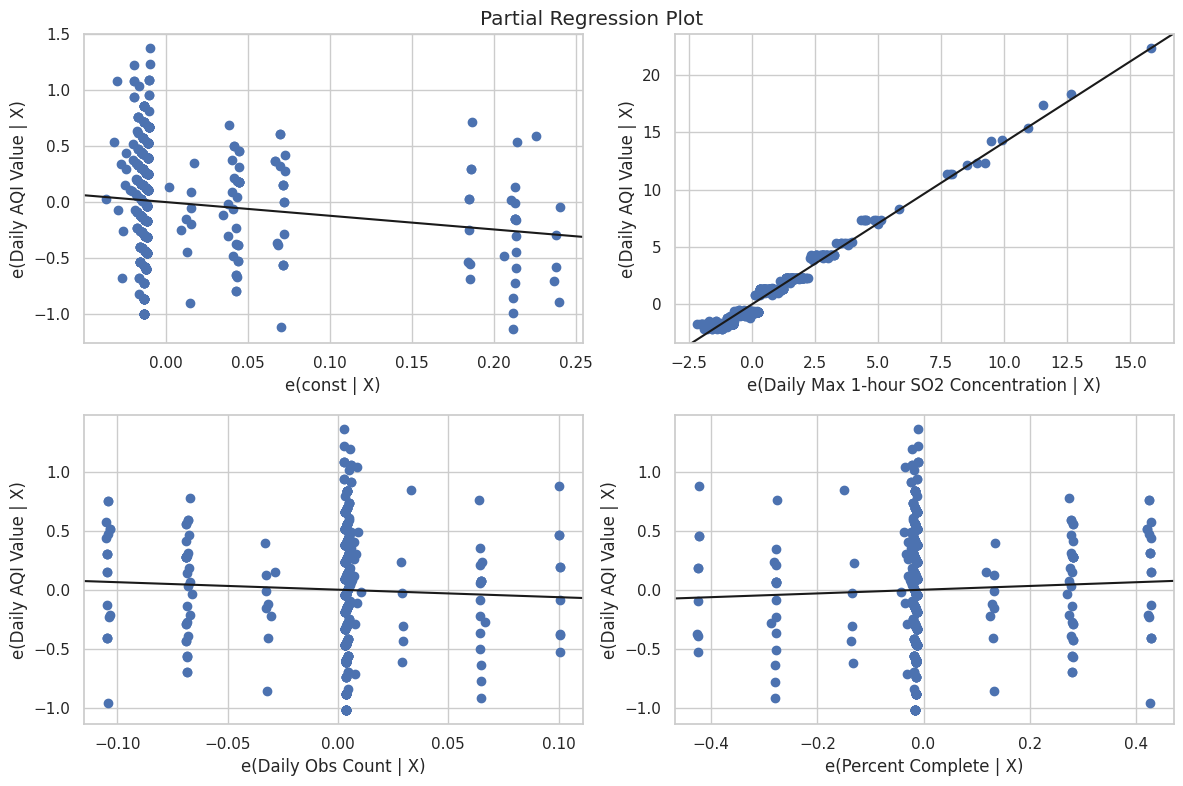

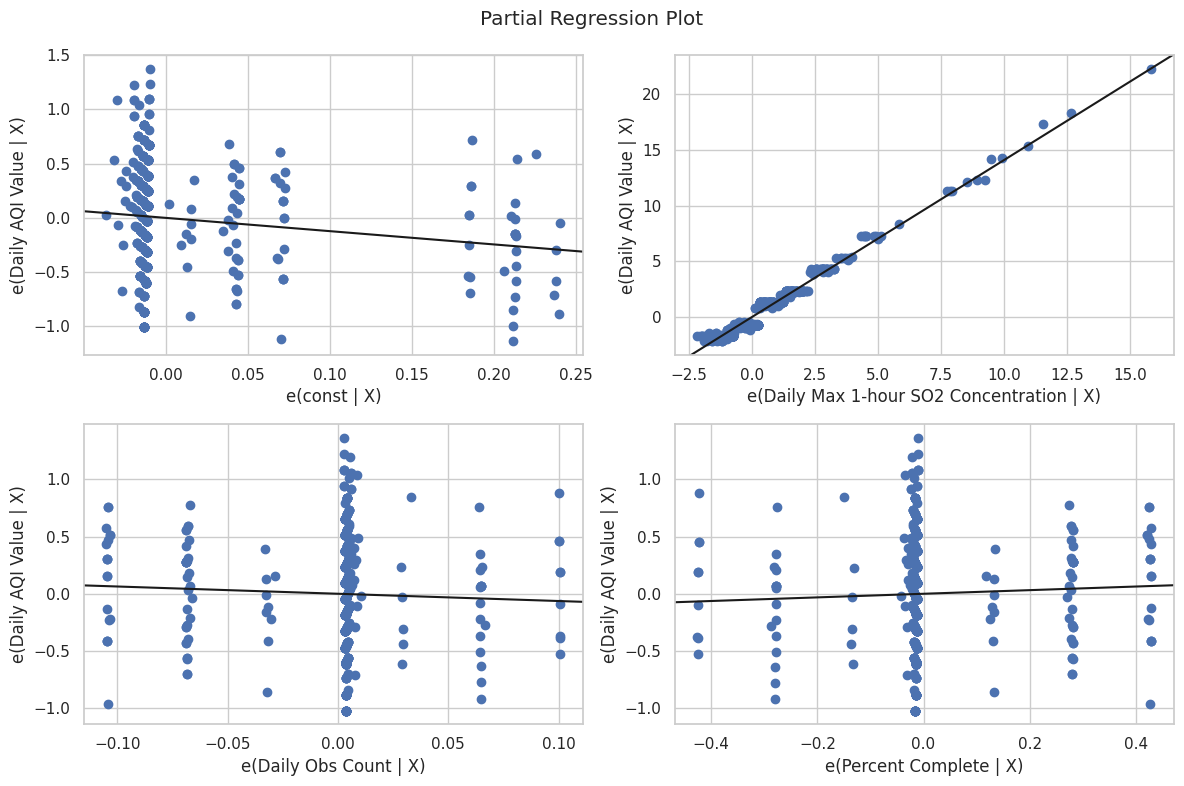

In [121]:
# Generar gráfico de regresiÃ³n parcial de todas las variables
fig = plt.figure(figsize=(12, 8))
plot_partregress_grid(modelo_ols, fig=fig)
plt.tight_layout()
plt.show()